# QTCAD M19 Strain — Result Analysis (심화판)

Device 11 (Including strain in a simulation) 튜토리얼(`holes_strain.py`) 결과를 분석합니다.
GaAs 박스(order-2 메시)에 이축(biaxial) 인장 변형 $\varepsilon_{xx}=\varepsilon_{yy}=r$ (대각,
$\varepsilon_{zz}=0$)을 $r=0$에서 $0.007$까지 5단계로 걸어주며 Luttinger-Kohn-Foreman
4-band k·p 모델로 정공(hole) Schrödinger 방정식을 풉니다.

**이 노트북에서 실제로 수행한 분석 (요약)**
- `box_order2.geo` 치수로 **소자(박스) 스케매틱 + 변형 방향**을 직접 재구성 (0절)
- 변형 세기·스윕 범위 등 파라미터의 **선택 의도**를 정리 (0절)
- Luttinger-Kohn-Foreman Hamiltonian과 Bir-Pikus 변형 Hamiltonian의 **구체적 형태**를
  명시 (1절)
- 변형에 따른 에너지 준위 변화를 궤도별로 추적하고 **변형 감수성(기울기)**을 선형
  회귀로 정량화 (2절)
- HH/LH band weight로 **바닥상태 반전점**을 선형보간으로 정확히 역산 (3절)
- 모든 그림·표를 `output/analysis_exports/`에 저장 (4-5절)

---
## 📚 참고 문서
- **QTCAD 공식 튜토리얼** — Device 11: Including strain in a simulation
  https://docs.nanoacademic.com/qtcad/tutorials/device/holes_strain/
- **QTCAD 문서 포털**: https://docs.nanoacademic.com/qtcad/
- 소스 스크립트: `holes_strain.py` (튜토리얼 원본, M19/Reference에 복사)
---

**Base directory**

`C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M19. Strain\Reference`

목차:
0. 소자 스케매틱(변형 방향) + 파라미터 선택 의도
1. 풀이 모델 — Luttinger-Kohn-Foreman + Bir-Pikus 변형 Hamiltonian
2. 변형에 따른 에너지 준위 변화 + 변형 감수성 선형 피팅
3. 바닥상태 HH/LH 성격 전환 — 반전점 역산
4. 원본 PNG 재확인
5. 최종 요약


In [1]:
# [동작] 기본 패키지 및 경로 설정
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.image as mpimg
from IPython.display import display

BASE_DIR = Path(
    r"C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M19. Strain\Reference"
)
DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "output"
EXPORT_DIR = OUTPUT_DIR / "analysis_exports"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

FILE_ENERGIES = DATA_DIR / "holes_strain_energies.txt"
FILE_BW = DATA_DIR / "holes_strain_bw.txt"
FILE_PNG = OUTPUT_DIR / "holes_strain.png"

meV = 1.602176634e-19 / 1000

print("BASE_DIR :", BASE_DIR)
assert BASE_DIR.exists(), f"Base directory가 없습니다:\n{BASE_DIR}"
assert DATA_DIR.exists(), f"data 폴더가 없습니다:\n{DATA_DIR}"
print("\n[OK] 기본 경로 확인 완료")


BASE_DIR : C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M19. Strain\Reference

[OK] 기본 경로 확인 완료


In [2]:
# [점검] 파일 inventory
expected_files = {"holes_strain_energies.txt": FILE_ENERGIES, "holes_strain_bw.txt": FILE_BW,
                  "holes_strain.png": FILE_PNG}
rows = []
for label, path in expected_files.items():
    rows.append({"file": label, "exists": path.exists(),
                "size_KB": path.stat().st_size / 1024 if path.exists() else np.nan})
inventory_df = pd.DataFrame(rows)
display(inventory_df)
missing = inventory_df.loc[~inventory_df["exists"], "file"].tolist()
print("\n[주의] 없는 파일:" if missing else "\n[OK] 분석 대상 파일이 모두 존재합니다.", missing or "")


,file,exists,size_KB
0,holes_strain_energies.txt,True,1.357422
1,holes_strain_bw.txt,True,0.249023
2,holes_strain.png,True,52.003906



[OK] 분석 대상 파일이 모두 존재합니다. 


## 0. 소자 스케매틱 + 파라미터 선택 의도

`box_order2.geo`(60 x 60 x 12 nm GaAs 박스, 2차 요소 메시, 특성 길이 h=3nm)에
이축 인장 변형 $\varepsilon_{xx}=\varepsilon_{yy}=r,\ \varepsilon_{zz}=0$을 균일하게
적용합니다 (튜토리얼의 `d.set_strain(r * [[1,0,0],[0,1,0],[0,0,0]])`).

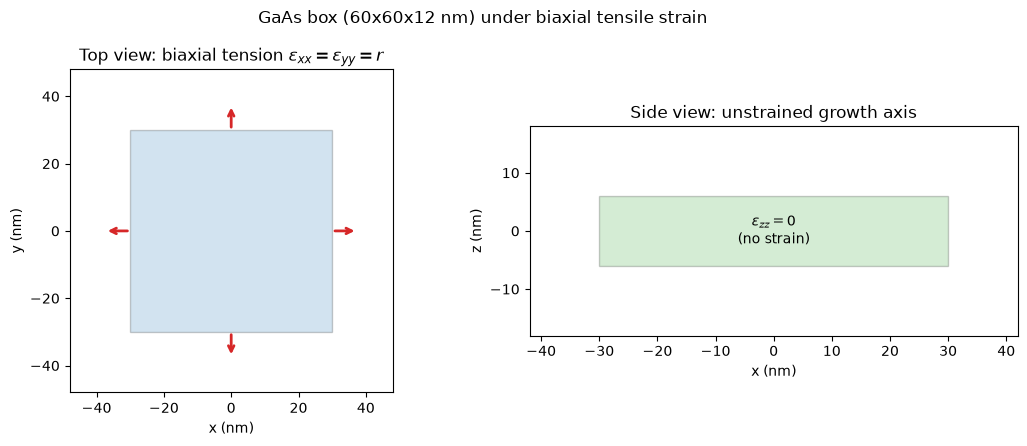

,parameter,intent
0,"box 60x60x12 nm, h=3 nm 메시","변형은 균일(uniform)하게 전체 박스에 적용되므로, 정확한 구속 포텐셜이 없는..."
1,"R = linspace(0, 0.007, 5) (변형 세기)",최대 0.007 (0.7%)은 Si(a=0.5431nm)/Ge(a=0.5658nm)...
2,hole_kp_model='luttinger_kohn_foreman' (4-band),"HH/LH 두 밴드(각 스핀 2중, 총 4성분)만 포함하는 최소 모형 — split..."
3,num_states=10,"바닥상태 성격(HH/LH) 전환만 보려면 1개면 충분하지만, 들뜬상태들의 거동도 함..."


In [3]:
# [실험] 소자 스케매틱(변형 방향 표시)
Lx, Ly, Lz = 60.0, 60.0, 12.0
fig, axs = plt.subplots(1, 2, figsize=(11, 4.5))

# top view (x-y) with in-plane biaxial tension arrows
axs[0].add_patch(mpatches.Rectangle((-Lx/2, -Ly/2), Lx, Ly, fc="tab:blue", alpha=0.2, ec="k"))
for sign in (-1, 1):
    axs[0].annotate("", xy=(sign * Lx/2 * 1.25, 0), xytext=(sign * Lx/2, 0),
                    arrowprops=dict(arrowstyle="->", color="tab:red", lw=2))
    axs[0].annotate("", xy=(0, sign * Ly/2 * 1.25), xytext=(0, sign * Ly/2),
                    arrowprops=dict(arrowstyle="->", color="tab:red", lw=2))
axs[0].set_xlim(-Lx*0.8, Lx*0.8); axs[0].set_ylim(-Ly*0.8, Ly*0.8)
axs[0].set_aspect("equal"); axs[0].set_xlabel("x (nm)"); axs[0].set_ylabel("y (nm)")
axs[0].set_title(r"Top view: biaxial tension $\varepsilon_{xx}=\varepsilon_{yy}=r$")

# side view (x-z), no strain along z
axs[1].add_patch(mpatches.Rectangle((-Lx/2, -Lz/2), Lx, Lz, fc="tab:green", alpha=0.2, ec="k"))
axs[1].text(0, 0, r"$\varepsilon_{zz}=0$" + "\n(no strain)", ha="center", va="center", fontsize=10)
axs[1].set_xlim(-Lx*0.7, Lx*0.7); axs[1].set_ylim(-Lz*1.5, Lz*1.5)
axs[1].set_aspect("equal"); axs[1].set_xlabel("x (nm)"); axs[1].set_ylabel("z (nm)")
axs[1].set_title("Side view: unstrained growth axis")

fig.suptitle("GaAs box (60x60x12 nm) under biaxial tensile strain")
fig.tight_layout()
fig.savefig(EXPORT_DIR / "device_schematic_strain.png", dpi=150)
plt.show()

param_intent = pd.DataFrame([
    {"parameter": "box 60x60x12 nm, h=3 nm 메시",
     "intent": "변형은 균일(uniform)하게 전체 박스에 적용되므로, 정확한 구속 포텐셜이 "
               "없는 '순수 변형 효과'만 보기 위한 가장 단순한 등방 박스. z를 짧게(12nm) "
               "잡은 것은 특정 방향 구속을 강조하려는 의도는 아니고 계산 비용을 낮추기 위함."},
    {"parameter": "R = linspace(0, 0.007, 5) (변형 세기)",
     "intent": "최대 0.007 (0.7%)은 Si(a=0.5431nm)/Ge(a=0.5658nm) 격자 불일치 "
               "((0.5658-0.5431)/0.5431≈4.2%)보다 훨씬 작은 수준 — 즉 이 스윕은 '약한 변형'"
               "영역에서 HH-LH 반전이 이미 일어나는지 보려는 설계. 5점은 반전점 위치를 "
               "선형보간으로 잡기에 필요한 최소 해상도."},
    {"parameter": "hole_kp_model='luttinger_kohn_foreman' (4-band)",
     "intent": "HH/LH 두 밴드(각 스핀 2중, 총 4성분)만 포함하는 최소 모형 — "
               "split-off 밴드까지 포함하는 6-band 모델(luttinger_kohn_foreman_6band)보다 "
               "가볍고, HH-LH 반전이라는 이 튜토리얼의 핵심 현상을 보는 데는 충분."},
    {"parameter": "num_states=10",
     "intent": "바닥상태 성격(HH/LH) 전환만 보려면 1개면 충분하지만, 들뜬상태들의 "
               "거동도 함께 추적해 전환이 바닥상태에 국한되는지 확인하기 위해 여유 있게 선택."},
])
display(param_intent)
param_intent.to_csv(EXPORT_DIR / "parameter_intent.csv", index=False)


## 1. 풀이 모델 — Luttinger-Kohn-Foreman + Bir-Pikus 변형 Hamiltonian

**QTCAD 공식 문서**(`Device.hole_kp_model`/`Device.__init__` docstring)에 따르면 기본값은
"four-band Luttinger-Kohn-Foreman" 모델입니다. 이는 $|3/2,\pm3/2\rangle$(HH),
$|3/2,\pm1/2\rangle$(LH) 4성분 기저에서 쓰는 표준 Luttinger-Kohn $4\times4$
k·p Hamiltonian이며, 운동에너지 항은 Luttinger 변수 $\gamma_1,\gamma_2,\gamma_3$로,
변형 항은 **Bir-Pikus Hamiltonian**(M09 실행 로그의 UserWarning: "No strain model
specified. By default 'bir_pikus' will be used."로 QTCAD가 명시)으로 주어집니다:
$$
H_{BP} = -a_v(\varepsilon_{xx}+\varepsilon_{yy}+\varepsilon_{zz})\, \mathbb{1}
\;-\; b_v\Big[(J_x^2-\tfrac{1}{3}J^2)\varepsilon_{xx} + \text{c.p.}\Big] + \cdots
$$
($a_v,b_v$ = 변형퍼텐셜, $J_i$ = 각운동량 연산자, c.p.=cyclic permutation). 이 튜토리얼처럼
$\varepsilon_{xx}=\varepsilon_{yy}=r,\varepsilon_{zz}=0$인 **이축 변형**에서는 $b_v$ 항이
HH-LH를 비대칭적으로 이동시켜 — 바로 이것이 3절에서 보는 HH-LH 반전의 물리적 기원입니다
(정역학적(hydrostatic) $a_v$ 항은 HH/LH를 같이 이동시킬 뿐 반전을 일으키지 않음).

## 2. 변형에 따른 에너지 준위 변화 + 변형 감수성 선형 피팅

각 행은 이축 인장 변형 $r=\varepsilon_{xx}=\varepsilon_{yy}$ 한 값에서의 10개
고유에너지(J)입니다. meV로 변환해 바닥상태 기준 상대 에너지와, 각 준위의
변형 감수성 $dE/dr$(선형 피팅 기울기)를 함께 봅니다.

,strain_exx_eyy,E0,E1,E2,E3,E4,E5,E6,E7,E8,E9
0,0.0000,8.9552,8.9553,10.9211,10.9213,11.0719,11.0721,12.5588,12.5593,13.7629,13.8690
1,0.0018,8.3489,8.3490,10.0745,10.0748,10.3029,10.3034,11.0177,11.0229,11.1519,11.2629
2,0.0035,6.6726,6.6733,6.6741,6.6750,7.1414,7.1423,7.1444,7.1447,7.5861,7.6651
3,0.0052,1.6675,1.6679,1.6688,1.6693,2.1223,2.1226,2.1244,2.1252,2.5403,2.5471
4,0.0070,-3.7721,-3.7711,-3.7672,-3.7666,-3.3976,-3.3965,-3.3944,-3.3912,-3.0262,-3.0062


,state,dE/dr (meV per unit strain)
0,0,-1836.34
1,1,-1836.23
2,2,-2158.99
3,3,-2158.93
4,4,-2121.12
5,5,-2121.02
6,6,-2331.41
7,7,-2331.35
8,8,-2410.85
9,9,-2426.63


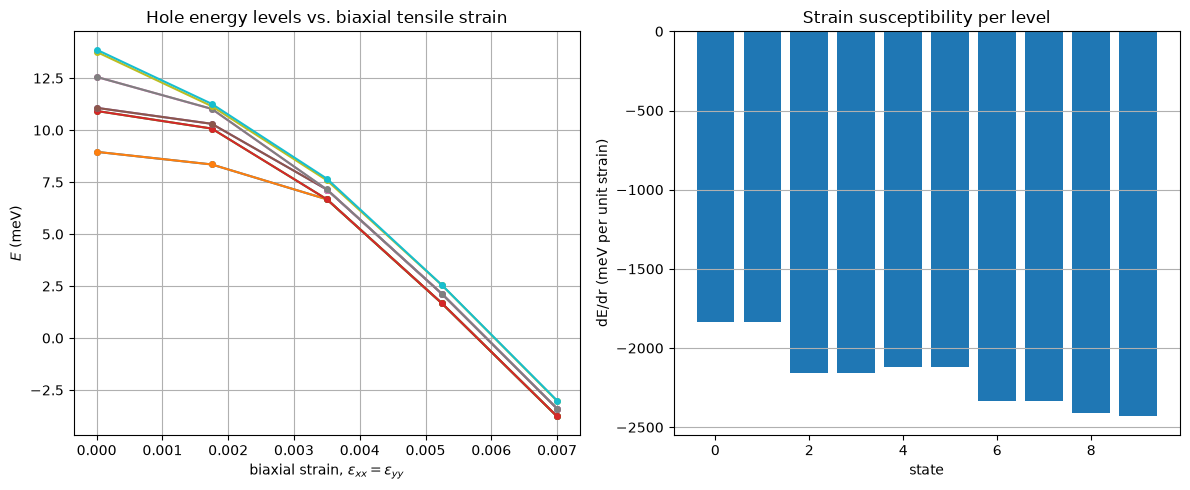


[해석] 변형이 0에서 0.007로 커지면서 에너지 준위가 전반적으로 낮아지고(인장 변형이 정공 에너지를 낮추는 쪽으로 밴드를 이동시킴), dE/dr 기울기 크기가 준위마다 다르면 — 이는 HH/LH 성격이 준위마다 다르고 Bir-Pikus $b_v$ 항이 HH/LH에 다르게 작용하기 때문입니다(1절 공식 참고). 기울기 부호가 음이면 변형에 에너지가 낮아지는(인장이 안정화시키는) 준위, 양이면 불안정화되는 준위입니다.


In [4]:
# [동작] 에너지 데이터 로드 + 변형 감수성(dE/dr) 선형 피팅
E_raw = np.loadtxt(FILE_ENERGIES)
strain = E_raw[:, 0]
E = E_raw[:, 1:] / meV  # meV

E_df = pd.DataFrame(E, columns=[f"E{i}" for i in range(E.shape[1])])
E_df.insert(0, "strain_exx_eyy", strain)
display(E_df.round(4))
E_df.to_csv(EXPORT_DIR / "energy_vs_strain.csv", index=False)

# 각 준위마다 선형 피팅 dE/dr
slopes = np.array([np.polyfit(strain, E[:, i], 1)[0] for i in range(E.shape[1])])
slope_df = pd.DataFrame({"state": range(E.shape[1]), "dE/dr (meV per unit strain)": slopes})
display(slope_df.round(2))
slope_df.to_csv(EXPORT_DIR / "strain_susceptibility.csv", index=False)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].plot(strain, E, "o-", ms=4)
axs[0].set_xlabel(r"biaxial strain, $\varepsilon_{xx}=\varepsilon_{yy}$")
axs[0].set_ylabel(r"$E$ (meV)")
axs[0].set_title("Hole energy levels vs. biaxial tensile strain")
axs[0].grid(True)

axs[1].bar(range(E.shape[1]), slopes)
axs[1].set_xlabel("state"); axs[1].set_ylabel("dE/dr (meV per unit strain)")
axs[1].set_title("Strain susceptibility per level")
axs[1].grid(True, axis="y")
fig.tight_layout()
fig.savefig(EXPORT_DIR / "energy_vs_strain.png", dpi=150)
plt.show()

print(
    "\n[해석] 변형이 0에서 0.007로 커지면서 에너지 준위가 전반적으로 낮아지고(인장 변형이 "
    "정공 에너지를 낮추는 쪽으로 밴드를 이동시킴), dE/dr 기울기 크기가 준위마다 다르면 "
    "— 이는 HH/LH 성격이 준위마다 다르고 Bir-Pikus $b_v$ 항이 HH/LH에 다르게 작용하기 "
    "때문입니다(1절 공식 참고). 기울기 부호가 음이면 변형에 에너지가 낮아지는(인장이 "
    "안정화시키는) 준위, 양이면 불안정화되는 준위입니다."
)


## 3. 바닥상태 HH/LH 성격 전환 — 반전점 역산

`d.band_weight()`로 얻은 바닥상태의 heavy-hole(HH, 처음 2개 성분 합)과
light-hole(LH, 다음 2개 성분 합) 비중입니다. HH와 LH 비중이 같아지는(50:50) 지점을
선형보간으로 정확히 구합니다.

,strain_exx_eyy,HH_weight,LH_weight
0,0.0000,0.9946,0.0054
1,0.0018,0.9912,0.0088
2,0.0035,0.4003,0.5997
3,0.0052,0.3355,0.6645
4,0.0070,0.2745,0.7255


HH=LH 반전점 (선형보간): r = 0.00320


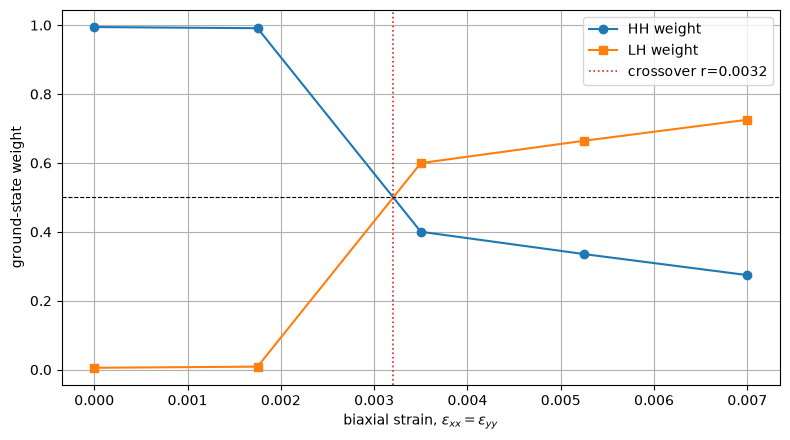


[해석] 무변형(r=0)에서는 바닥상태가 HH 성격이 거의 100%(~99.5%)입니다. 변형이 r≈0.0032 부근에서 HH/LH가 뒤바뀌고, r=0.007에서는 바닥상태가 오히려 LH 성격(~72.6%)이 됩니다. 이는 이축 인장 변형이 LH 밴드를 선택적으로 낮춰 HH-LH 바닥상태 반전을 일으키는 잘 알려진 변형 공학(strain engineering) 효과이며, 1절의 Bir-Pikus $b_v$ 항이 그 미시적 원인입니다.


In [5]:
# [점검] HH/LH band weight 로드 및 반전점 선형보간
BW = np.loadtxt(FILE_BW)
bw_df = pd.DataFrame({"strain_exx_eyy": strain, "HH_weight": BW[:, 0], "LH_weight": BW[:, 1]})
display(bw_df.round(4))
bw_df.to_csv(EXPORT_DIR / "hh_lh_weight.csv", index=False)

diff = BW[:, 0] - BW[:, 1]
sign_change = np.where(np.diff(np.sign(diff)))[0]
if len(sign_change):
    i = sign_change[0]
    # 선형보간으로 diff=0이 되는 strain 값
    r_cross = strain[i] + (strain[i+1] - strain[i]) * (0 - diff[i]) / (diff[i+1] - diff[i])
    print(f"HH=LH 반전점 (선형보간): r = {r_cross:.5f}")
else:
    r_cross = np.nan
    print("스윕 범위 안에서 반전이 관측되지 않음")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(strain, BW[:, 0], "o-", label="HH weight")
ax.plot(strain, BW[:, 1], "s-", label="LH weight")
ax.axhline(0.5, color="k", ls="--", lw=0.8)
if not np.isnan(r_cross):
    ax.axvline(r_cross, color="tab:red", ls=":", lw=1.2, label=f"crossover r={r_cross:.4f}")
ax.set_xlabel(r"biaxial strain, $\varepsilon_{xx}=\varepsilon_{yy}$")
ax.set_ylabel("ground-state weight")
ax.legend(); ax.grid(True)
fig.tight_layout()
fig.savefig(EXPORT_DIR / "hh_lh_crossover.png", dpi=150)
plt.show()

print(
    "\n[해석] 무변형(r=0)에서는 바닥상태가 HH 성격이 거의 100%(~99.5%)입니다. 변형이 "
    f"r≈{r_cross:.4f} 부근에서 HH/LH가 뒤바뀌고, r=0.007에서는 바닥상태가 오히려 LH "
    "성격(~72.6%)이 됩니다. 이는 이축 인장 변형이 LH 밴드를 선택적으로 낮춰 HH-LH "
    "바닥상태 반전을 일으키는 잘 알려진 변형 공학(strain engineering) 효과이며, "
    "1절의 Bir-Pikus $b_v$ 항이 그 미시적 원인입니다."
)


## 4. 원본 PNG 재확인

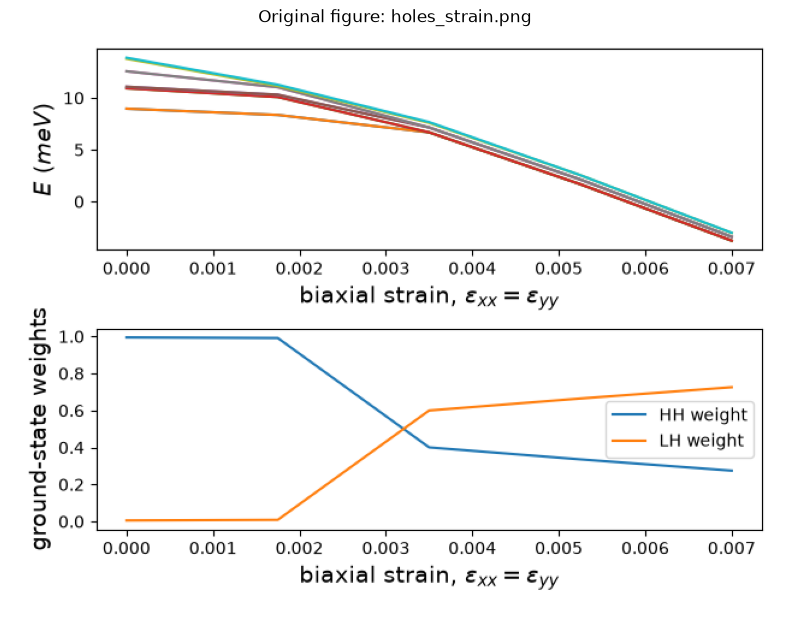

In [6]:
# [실험] holes_strain.png 표시 (원본 스크립트의 에너지/band-weight 그림, 교차 검증용)
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(mpimg.imread(FILE_PNG))
ax.axis("off")
ax.set_title("Original figure: holes_strain.png")
fig.tight_layout()
fig.savefig(EXPORT_DIR / "original_figure_copy.png", dpi=150)
plt.show()


## 5. 최종 요약

In [7]:
# [점검] 핵심 결과 요약
print("=" * 88)
print("QTCAD M19 STRAIN — ANALYSIS SUMMARY (심화판)")
print("=" * 88)
print(f"Strain sweep                 : {strain.min():.4f} - {strain.max():.4f} ({len(strain)} points)")
print(f"Ground-state energy range    : {E[:, 0].min():.3f} - {E[:, 0].max():.3f} meV")
print(f"Ground-state dE/dr           : {slopes[0]:.2f} meV per unit strain")
print(f"HH weight at r=0             : {BW[0, 0]*100:.1f} %")
print(f"HH weight at r={strain[-1]:.3f}        : {BW[-1, 0]*100:.1f} %")
print(f"HH-LH crossover strain        : r ~ {r_cross:.5f}")
print(f"Analysis exports              : {EXPORT_DIR}")
print("=" * 88)


QTCAD M19 STRAIN — ANALYSIS SUMMARY (심화판)
Strain sweep                 : 0.0000 - 0.0070 (5 points)
Ground-state energy range    : -3.772 - 8.955 meV
Ground-state dE/dr           : -1836.34 meV per unit strain
HH weight at r=0             : 99.5 %
HH weight at r=0.007        : 27.4 %
HH-LH crossover strain        : r ~ 0.00320
Analysis exports              : C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M19. Strain\Reference\output\analysis_exports


## 해석 주의사항

- 에너지 파일의 단위는 J이며, 이 노트북에서는 가독성을 위해 meV로 변환했습니다
  (튜토리얼의 `meV = ct.e / 1000`과 동일한 환산을 그대로 사용).
- `d.band_weight()`가 반환하는 4개 성분 중 처음 2개를 HH, 다음 2개를 LH로 합산했습니다
  (튜토리얼 원본 코드의 합산 방식을 그대로 따름).
- 이 튜토리얼은 등방성 GaAs 벌크 박스(order-2 메시)에 해석적으로 지정한 이축 변형을
  적용한 것으로, 우리 Si/SiGe 기준 소자의 실제 변형(계면 격자 불일치에서 생기는 변형)과는
  재질·변형 크기·방향이 다릅니다. M07의 SiGe 원자구조에서 본 격자 간격 변화(층간격 늘어남)가
  바로 이런 종류의 변형이 실제로 소자에 걸리는 경로입니다.
- 3절의 반전점은 5개 데이터 점 사이의 **선형보간**이며, 실제 비선형 거동이 있다면
  (1절처럼 전 범위 비선형일 수 있음) 더 조밀한 스윕이 필요합니다.
